# Cell 1: Đọc và kiểm tra tổng quan dữ liệu


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Đọc file dữ liệu bạn vừa tải
df = pd.read_csv('../data/raw/7282_1.csv')

# In ra số lượng dòng, cột và 5 dòng đầu tiên
print(f"Kích thước ban đầu: {df.shape}")
display(df[['name', 'reviews.rating', 'reviews.text']].head())

Kích thước ban đầu: (35912, 19)


,name,reviews.rating,reviews.text
0,Hotel Russo Palace,4.0,Pleasant 10 min walk along the sea front to th...
1,Hotel Russo Palace,5.0,Really lovely hotel. Stayed on the very top fl...
2,Hotel Russo Palace,5.0,Ett mycket bra hotell. Det som drog ner betyge...
3,Hotel Russo Palace,5.0,We stayed here for four nights in October. The...
4,Hotel Russo Palace,5.0,We stayed here for four nights in October. The...


# cell 2: Làm sạch cơ bản


In [11]:
# Đếm số lượng dữ liệu bị thiếu ở các cột quan trọng
print("Dữ liệu thiếu trước khi lọc:")
print(df[['reviews.rating', 'reviews.text']].isnull().sum())

# Bỏ các dòng không có điểm rating hoặc text, và xóa đánh giá trùng lặp
df = df.dropna(subset=['reviews.rating', 'reviews.text'])
df = df.drop_duplicates(subset=['reviews.text'])

print(f"\nKích thước sau khi làm sạch cơ bản: {df.shape}")

Dữ liệu thiếu trước khi lọc:
reviews.rating    862
reviews.text       24
dtype: int64

Kích thước sau khi làm sạch cơ bản: (33629, 19)


# Cell 3: Biểu đồ 1 - Phân phối điểm rating

C:\Users\Admin\AppData\Local\Temp\ipykernel_6444\3471269998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='reviews.rating', palette='viridis', order=[1.0, 2.0, 3.0, 4.0, 5.0])


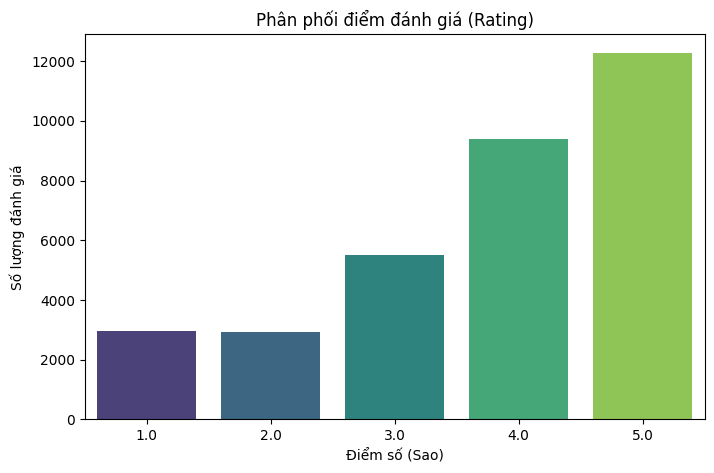

In [12]:
plt.figure(figsize=(8, 5))

# Vẽ biểu đồ với các mức điểm từ 1.0 đến 5.0
sns.countplot(data=df, x='reviews.rating', palette='viridis', order=[1.0, 2.0, 3.0, 4.0, 5.0])

plt.title('Phân phối điểm đánh giá (Rating)')
plt.xlabel('Điểm số (Sao)')
plt.ylabel('Số lượng đánh giá')
plt.show()

# cell 4: Biểu đồ 2 - Top 20 từ xuất hiện nhiều nhất

C:\Users\Admin\AppData\Local\Temp\ipykernel_6444\1428102519.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_words_df, x='Count', y='Word', palette='magma')


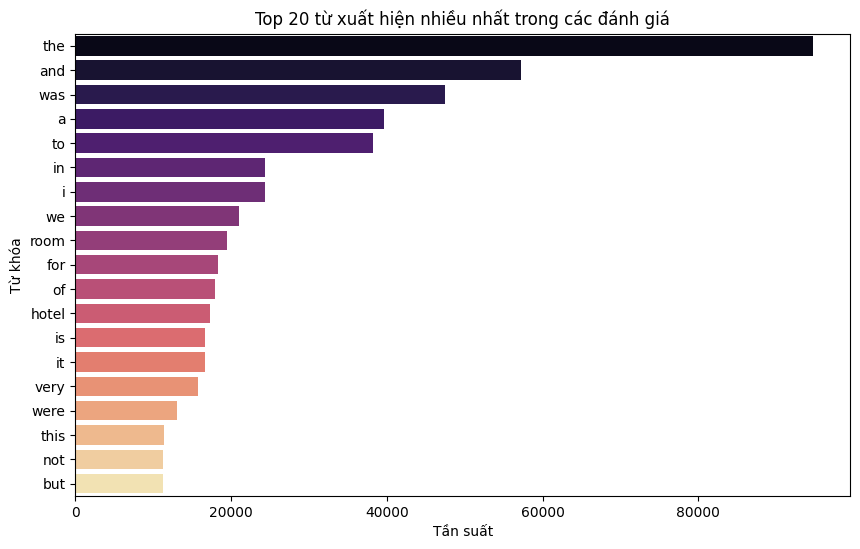

In [13]:
def clean_text_basic(text):
    text = str(text).lower()
    # Chỉ giữ lại chữ cái và khoảng trắng
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Tách từ và đếm tần suất
words = df['reviews.text'].apply(clean_text_basic).str.split(expand=True).stack()
word_counts = Counter(words).most_common(20)

top_words_df = pd.DataFrame(word_counts, columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(data=top_words_df, x='Count', y='Word', palette='magma')
plt.title('Top 20 từ xuất hiện nhiều nhất trong các đánh giá')
plt.xlabel('Tần suất')
plt.ylabel('Từ khóa')
plt.show()